In [1]:
import sys
print(sys.executable)

import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# EEGNet-specific imports
from EEGModels import EEGNet
from tensorflow.keras import utils as np_utils
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import backend as K

import tensorflow.keras as keras
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.constraints import max_norm
from tensorflow.keras import backend as K
import tensorflow.keras.models as models
import tensorflow.compat.v1 as tf
import numpy as np
from tslearn.metrics import soft_dtw
import os
import mne
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Activation, Permute, Dropout, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D
from tensorflow.keras.layers import SeparableConv2D, DepthwiseConv2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import SpatialDropout2D
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.layers import Input, Flatten
from tensorflow.keras.constraints import max_norm
from tensorflow.keras import backend as K
from scipy.signal import butter, filtfilt
from sklearn.model_selection import KFold
from scipy import io, signal
import math

C:\Users\qianqian\AppData\Local\Programs\Python\Python312\python.exe


In [2]:
import random

# Set a fixed seed value
SEED = 42

# Set seed for TensorFlow 1.x
tf.compat.v1.set_random_seed(SEED)

# Set seed for NumPy
np.random.seed(SEED)

# Set seed for Python's random module
random.seed(SEED)

# Ensure deterministic behavior for some TensorFlow operations
os.environ["TF_DETERMINISTIC_OPS"] = "1"

tf.compat.v1.reset_default_graph()

In [3]:
chans = 64
kernels = 1
n_subjects = 3
n_start = 500
n_freqs = 10
n_trials = 6
# parameters for Butterworth filter
lowcut1 = 10
lowcut2 = 8
lowcut3 = 9
highcut = 90
fs = 250
# parameters for data segment
seg_length= 250
n_seg = 4

#experiment
leave_one_out = False 

In [4]:
def bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyq  = 0.5 * fs  # Nyquist Frequency
    low  = lowcut / nyq
    high = highcut /nyq
    b, a = butter(order, [low, high], btype='band')
    y    = lfilter(b, a, data)
    return y

In [5]:
def filter_set(data_set, lowcut, highcut, fs, order=5):
    filtered_set = np.zeros_like(data_set)
    for i in range(data_set.shape[0]):
        for j in range(data_set.shape[1]):
            filtered_set[i, j, :] = bandpass_filter(data_set[i, j, :], lowcut1, highcut, fs, order=5)
    return filtered_set

In [6]:
selected_subjects_keys = [f"S{i}" for i in range(1, n_subjects+1)] #n_subjects+1
seg_data = {}
subject_data = {}
for i in range(1, n_subjects+1):
    file_path = f'D://2024//7-9//dissertation//code//S{i}.mat'
    subject_data[f'S{i}'] = scipy.io.loadmat(file_path)['data']

In [7]:
import random

# Set a fixed seed value
SEED = 42

# Set seed for TensorFlow 1.x
tf.compat.v1.set_random_seed(SEED)

# Set seed for NumPy
np.random.seed(SEED)

# Set seed for Python's random module
random.seed(SEED)

# Ensure deterministic behavior for some TensorFlow operations
os.environ["TF_DETERMINISTIC_OPS"] = "1"

tf.compat.v1.reset_default_graph()

# Example input data
freq_indices = []
data = subject_data['S3']
optimal_channels = [46,47,49, 52, 55, 58 , 60, 61, 62]
data = data[optimal_channels, 250:1250, :, :]

# Prepare lists for train/test sets
X_train, Y_train = [], []
X_test, Y_test = [], []

for target in range(10):  # Loop over targets
    for trial in range(6):  # Loop over trials
        for i in range(4):  # 4 segments per trial
            start = i * 250
            end = (i + 1) * 250
            segment = data[:, start:end, target, trial]

            if trial < 5:  # Use first 4 trials for training
                X_train.append(segment)
                Y_train.append(target)
            else:  # Use last 2 trials for testing
                X_test.append(segment)
                Y_test.append(target)

# Convert lists to numpy arrays
X_train = np.array(X_train)  # (160, 64, 250)
Y_train = np.array(Y_train)  # (160,)
X_test = np.array(X_test)    # (80, 64, 250)
Y_test = np.array(Y_test)    # (80,)

Y_train = np_utils.to_categorical(Y_train, num_classes=10)  # Shape: (160, 10)
Y_test = np_utils.to_categorical(Y_test, num_classes=10)    # Shape: (80, 10)

X_train = filter_set(X_train, lowcut1, highcut, fs, 4)
X_test = filter_set(X_test, lowcut1, highcut, fs, 4)

eeg_model = EEGNet(nb_classes = 10, Chans = len(optimal_channels), Samples = 250, 
            dropoutRate = 0.5, kernLength = 125, F1 = 8, D = 2, F2 = 12, 
            dropoutType = 'Dropout')
        
eeg_model.compile(loss='categorical_crossentropy', optimizer='adam', 
            metrics = ['accuracy'])

eeg_model.fit(X_train, Y_train, batch_size=16, epochs=125, shuffle=True, verbose=0, 
    validation_data=(X_test, Y_test))

    #Assess accuracy
score = eeg_model.evaluate(X_test, Y_test, verbose=0)
    #preds_eeg.append(eeg_model.predict(X_test))
print(f"EEGNET acc: {score[1]}", flush=True)

C:\Users\qianqian\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


EEGNET acc: 1.0


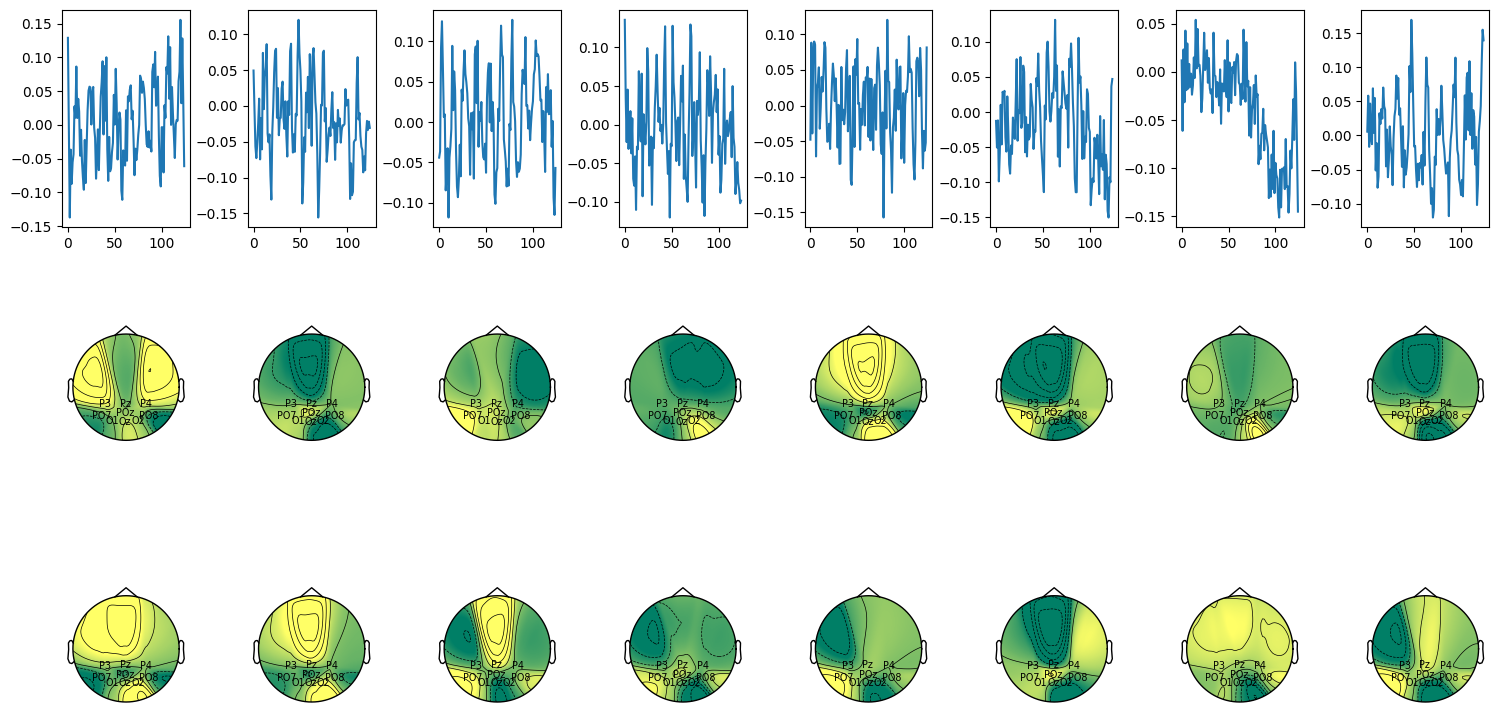

In [10]:

from mne.channels import make_standard_montage
from mne.viz import plot_topomap

def visualise_filters(trained_model, channels=['P3', 'Pz', 'P4', 'PO7', 'POz', 'O1', 'Oz', 'O2', 'PO8']):
    # chans: 每个空间滤波器在不同电极上的权重分布
    # F1: 空间滤波器的数量
    # depth filters: 每个空间滤波器的不同深度组件数量
    spatial_filters = np.array(eeg_model.layers[3].weights[0]).squeeze(1) #removes singleton dimension (chans, F1 ,depth filters)
    temporal_filters = np.array(eeg_model.layers[1].weights[0]).squeeze() # collapse singleton dimensions
    n_channels, n_filters, n_depth = spatial_filters.shape

    info = mne.create_info(ch_names=channels, sfreq=fs, ch_types='eeg')
    montage = make_standard_montage('standard_1020') # 创建一个基于国际10-20系统的标准电极位置蒙太奇 
    info.set_montage(montage)
    # 创建一个虚拟的Evoked对象，并将其与电极位置蒙太奇关联起来，提供一个包含通道信息和电极位置的模板对象，便于后续的可视化
    dummy_evoked = mne.EvokedArray(np.zeros((n_channels, 1)), info)
    dummy_evoked.set_montage(montage)

    rows, cols = n_filters, n_depth + 1 # 第一行分配给时间滤波器的子图，所以列数 = 空间滤波器的深度 + 1
    fig, axes = plt.subplots(cols, rows, figsize=(15, 8))
    #time_axis = np.linspace(0, 0.25, 125)  # From 0 to 0.5 seconds, 125 points
    fig.tight_layout()

    y_min = np.min(temporal_filters)
    y_max = np.max(temporal_filters)
    
    for i in range(n_filters):
        axes[0, i].plot(temporal_filters[:, i], label=f'Filter {i+1}')
        axes[0, i].set_ylim(y_min, y_max)
        axes[0, i].autoscale()
        for j in range(n_depth):
            filter_component = spatial_filters[:, i, j]
            # 从绿色到黄色的映射信号值越大颜色越亮
            plot_topomap(filter_component, dummy_evoked.info, names=channels, show=False, axes=axes[j+1,i], sensors=False, cmap='summer')

visualise_filters(eeg_model)
    
    

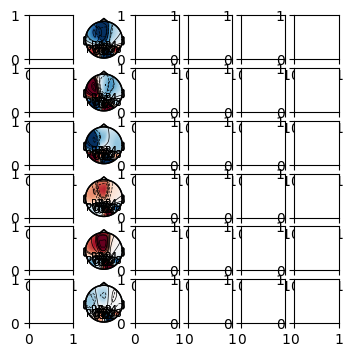

In [28]:
#CONV2D [1] Temporal?
#DepthwiseConv2D [3] Spatial?
from mne.channels import make_standard_montage
from mne.viz import plot_topomap

chans = ['P3', 'Pz', 'P4', 'PO7', 'POz', 'O1', 'Oz', 'O2', 'PO8']
spatial_filters = np.array(eeg_model.layers[3].weights[0]).squeeze(1) #removes singleton dimension (chans, F1 ,depth filters)
#print(spatial_filters.shape) # 9.1.6.2
n_channels, n_filters, components = spatial_filters.shape
sfreq = 1.0 # 250 
info = mne.create_info(ch_names=chans, sfreq=sfreq, ch_types='eeg')

montage = make_standard_montage('standard_1020')
info.set_montage(montage)
dummy_evoked = mne.EvokedArray(np.zeros((9, 1)), info)
dummy_evoked.set_montage(montage)

# Define grid layout
rows, cols = 1, 6  # 2 rows, 3 columns

# Create subplots
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(4, 4))

temporal_filters = np.array(eeg_model.layers[1].weights[0]).squeeze() # collapse singleton dimensions
time_axis = np.linspace(0, 0.25, 125)  # From 0 to 0.5 seconds, 125 points




for i in range(n_filters):
    #print(f"Filter {i+1}:")
    for component in range(components):
        filter_component = spatial_filters[:, i, component]
        #print(filter_component.shape)
        plot_topomap(filter_component, dummy_evoked.info, names=chans, show=False, axes=axes[i,1])

#fig.savefig("topomaps.png", dpi=300, bbox_inches="tight")  # High-quality save






In [ ]:
temporal_filters = np.array(eeg_model.layers[1].weights[0]).squeeze() # collapse singleton dimensions
time_axis = np.linspace(0, 0.25, 125)  # From 0 to 0.5 seconds, 125 points

for i in range(6):  # Loop through each filter
    plt.figure(figsize=(5, 5))
    plt.plot(time_axis, temporal_filters[:, i], label=f'Filter {i+1}')
    plt.show()


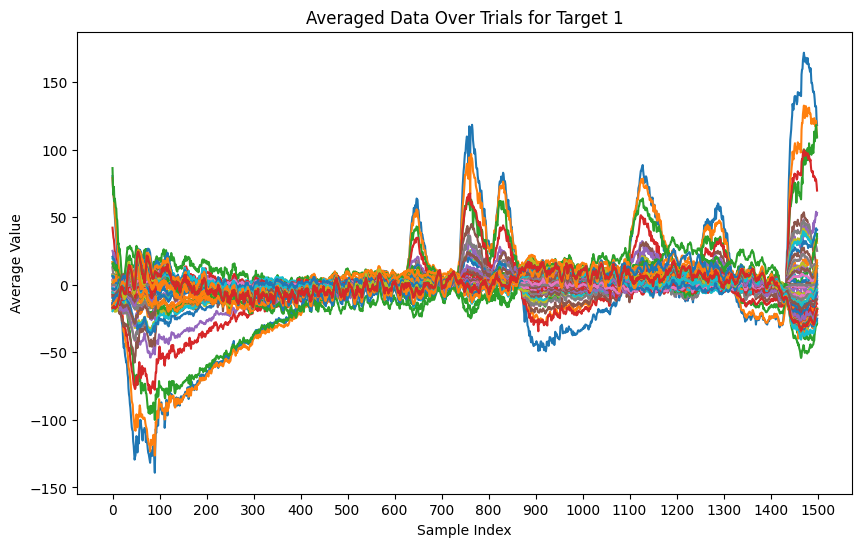

In [91]:
data = subject_data['S3'][:,:,:,:]


# Step 1: Choose one target (e.g., target 0)
target_index = 0  # or any other target index you want

# Step 2: Select the specific target (this reduces the shape to (64, 1500, 6))
data_target = data[:, :, target_index, :]  # Shape will be (64, 1500, 6)

# Step 3: Average across trials (axis 2), while keeping the target
data_avg = np.mean(data_target, axis=2)  # Shape will be (64, 1500)

# Step 4: Plot data for each channel (64 channels)
plt.figure(figsize=(10, 6))
for channel in range(data_avg.shape[0]):
    plt.plot(data_avg[channel, :], label=f'Channel {channel+1}')

# Step 5: Adjust x-axis ticks to make increments smaller (e.g., show every 10th tick)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True, prune='lower', nbins=20))  # Adjust nbins to your liking

plt.title(f'Averaged Data Over Trials for Target {target_index + 1}')
plt.xlabel('Sample Index')
plt.ylabel('Average Value')
#plt.legend()
plt.show()

In [ ]:
['P3', 'PZ', 'P4', 'PO7', 'POz', 'O1', 'Oz', 'O2', 'PO8']

46      47    49     52   55      60   61   62    58 
[46,47,49, 52, 55, 58 , 60, 61, 62]

In [ ]:
#eeg_model.load_weights("model.weights.h5")
#score = eeg_model.evaluate(X_test, Y_test, verbose=1)

for i in range(6):
    eeg_model.load_weights("model.weights.h5")
    temporal_filters = eeg_model.layers[1].weights[0].numpy()
    temporal_filters[:,:, :, i] = np.zeros((1,125,1))
    eeg_model.layers[1].weights[0].assign(temporal_filters)
    score = eeg_model.evaluate(X_test, Y_test, verbose=1)


In [ ]:
eeg_model.load_weights("model.weights.h5")
score = eeg_model.evaluate(X_test, Y_test, verbose=1)

for f in range(6):
    for d in range(2):
        print(f,d)
        eeg_model.load_weights("model.weights.h5")
        #spatial_filters = eeg_model.layers[3].weights[0].numpy()
        #spatial_filters[:, :, f, d] = np.zeros((9,1))
        #eeg_model.layers[3].weights[0].assign(spatial_filters)
        #score = eeg_model.evaluate(X_test, Y_test, verbose=0)
        #print(score[1])